In [1]:
from PIL import Image
from io import BytesIO
import requests
from ultralytics import YOLO
from matplotlib import pyplot as plt


url_image = "https://www.autostat.ru/application/includes/blocks/big_photo/images/cache/000/046/251/b7886bd8-670-0.jpg?_=1501573196"
#url_image = "https://porsche-rscar.ru/upload/store/p/img_news/Porsche_911_Carrera1.jpg"
#url_image = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQEEgDeMuvpVGGun8wYueWuKgzBK3KUUw-s2g&s"
response = requests.get(url=url_image)

img = Image.open( BytesIO(response.content))

In [7]:
!pip install nbformat

  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)


In [10]:
import torch
%run "./OCR_backbone.ipynb"
import json
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
from torchvision import transforms

class FinalPipeline:
    def __init__(self, checkpoint_path="crnn_numberplate_checkpoint.pth", device='cuda', detection_model_name="runs/detect/car_number_1105_ep50/weights/best.pt"):
        self.crops = []
        self.boxes = []
        self.predictions = []
        self.device = torch.device(device if torch.cuda.is_available() and device == 'cuda' else 'cpu')
        self.load_alphabet_config()
        self.init_detection_model(detection_model_name)
        self.init_recognition_model(checkpoint_path)
        self.original_image = None 
       
    def init_recognition_model(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        model_config = checkpoint['model_architecture']
        
        self.recognition_model = CRNN(
            img_h=model_config['img_height'],
            num_channels=1,
            num_classes=model_config['vocab_size']
        ).to(self.device)
        
        self.recognition_model.load_state_dict(checkpoint['model_state_dict'])
        self.recognition_model.eval()
        
    def init_detection_model(self, detection_model_name):
        self.detection_model = YOLO(detection_model_name) 
        
    def load_alphabet_config(self, config_path = "alphabet_config.json"):
        with open(config_path, 'r', encoding='utf-8') as f:
                vocab_data = json.load(f)
        self.alphabet = vocab_data['alphabet']
        self.blank_idx = vocab_data['blank_idx']
        self.char2idx = vocab_data['char2idx']
        self.idx2char = {int(k): v for k, v in vocab_data['idx2char'].items()}
        self.vocab_size = vocab_data['vocab_size']
    
    def preprocess_image_for_recognition(self, crop):
        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((32, 128)), 
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        
        img_tensor = transform(crop)
        return img_tensor.unsqueeze(0).to(self.device)  
        
    def crop(self, image):
        self.original_image = image.copy()
        results = self.detection_model(self.original_image)
        
        if len(results) > 0 and results[0].boxes is not None:
            for i, box in enumerate(results[0].boxes):
                box_coords = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, box_coords)
                
                crop = self.original_image.crop((x1, y1, x2, y2))
                self.crops.append(crop)
                self.boxes.append((x1, y1, x2, y2))
                plt.imshow(crop)
                plt.title(f"Crop {i+1}")
        
        print(f"Найдено кропов: {len(self.crops)}")
        return self.crops
    
    def detect(self):
        self.predictions = []
        
        for i, crop in enumerate(self.crops):
            img_tensor = self.preprocess_image_for_recognition(crop)
            
            with torch.no_grad():
                logits = self.recognition_model(img_tensor)
                pred = logits.permute(1, 0, 2).argmax(2)
                text = self.decode_sequence(pred[0])
            
            self.predictions.append(text)
            print(f"Номер {i+1}: {text}")
        
        return self.predictions
            
    def decode_sequence(self, seq):
        seq = seq.cpu().numpy().tolist()
        prev = None
        out = []
        for s in seq:
            if s != self.blank_idx and s != prev:
                if s in self.idx2char:
                    out.append(self.idx2char[s])
            prev = s
        return "".join(out)
            
    def visualize(self):
        if self.original_image is None or len(self.predictions) == 0:
            print("Нщмера не обнаружены")
            return
        
        img_display = np.array(self.original_image.copy())
        img_display = cv2.cvtColor(img_display, cv2.COLOR_RGB2BGR)
        
        for i, (box, text) in enumerate(zip(self.boxes, self.predictions)):
            x1, y1, x2, y2 = box
            cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_display, text, (x1, y1-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        plt.imshow(img_display)
        plt.show()
    
    def process(self, image):
        print("Детекция и кроп...")
        self.crop(image)
        
        if len(self.crops) > 0:
            print("\nРаспознавание текста...")
            self.detect()
            
            print("\nВизуализация...")
            self.visualize()
        else:
            print("Номерные знаки не найдены!")
        
        return self.predictions

CUDA


C:\Users\alina\AppData\Local\Temp\ipykernel_10016\479087886.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=self.d

Детекция и кроп...

0: 480x640 1 license_plate, 35.5ms
Speed: 5.0ms preprocess, 35.5ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Найдено кропов: 1

Распознавание текста...
Номер 1: X796BT178

Визуализация...


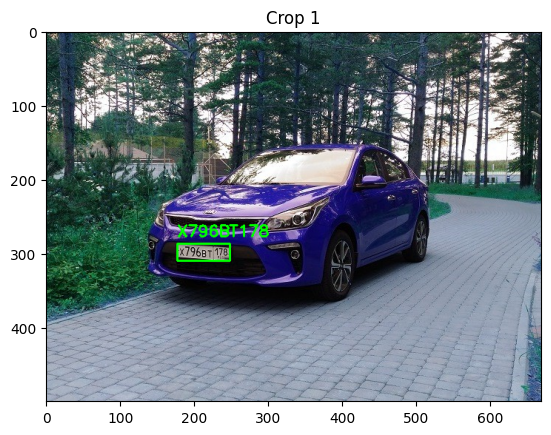

['X796BT178']

In [11]:
pipe = FinalPipeline()
pipe.process(img)